In [1]:
import torch
words = open('../names.txt', 'r').read().splitlines()

In [ ]:
N = torch.zeros((27, 27), dtype = torch.int32)
chars = sorted(list(set(''.join(words)))) # 把 words 这个字符串列表里的所有单词，拼接成一个大字符串，中间不加任何东西。
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi = string to integer
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [3]:
# creat the training set of bigrams (x, y)
xs , ys = [], []  #  输入字符 和 希望输出字符 的标签
# 这其实是标准的监督式学习

for w in words[:1]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]): 
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

# xs 和 ys 在后续用作索引，而很多索引操作要求整数
xs = torch.tensor(xs)  # 数据类型：tensor--int64，Tensor--float32
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [4]:
print(xs, ys)

tensor([ 0,  5, 13, 13,  1]) tensor([ 5, 13, 13,  1,  0])


In [5]:
import torch.nn.functional as F
# one-hot 的规则就是：一个向量里只有一个位置是 1，其余位置全部是 0；1 所在的位置表示类别编号。

xenc = F.one_hot(xs, num_classes = 27).float()  # 列表中1的位置代表 xs 和 ys 对应的数字
xenc
# 这就是神经网络真正可以拿来做矩阵乘法的输入形式


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [6]:
xenc.shape

torch.Size([5, 27])

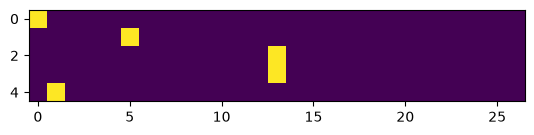

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(xenc)

In [8]:
# 神经网络里的核心计算，本质上几乎都是: 连续数值的加减乘除 + 梯度更新
# 整数不适合表达这种连续变化
# 所以我们希望 xenc.dtype 是浮点数
xenc.dtype


torch.float32

In [42]:
# 随机生成一个 27 × 27 的浮点权重矩阵，作为神经网络参数 W 的初始值
g = torch.Generator().manual_seed(2147483647 + 1)
W = torch.randn((27,27), generator = g)  # randn 生成的是服从标准正态分布的随机浮点数。
xenc @ W  # 矩阵乘法，就是“左边的行”去和“右边的列”做点积。

tensor([[-1.8466,  1.1186, -0.1104,  0.8080,  1.1208,  0.6045, -0.2629, -0.8401,
         -1.2115,  1.5081, -0.3306, -0.3676,  0.4935, -1.0824, -1.1730, -0.0739,
         -0.3131, -0.1387,  0.0370, -0.1308,  0.3529,  0.4702, -0.3813, -1.2174,
         -0.9630,  0.1225, -0.0106],
        [ 0.6082, -0.7220,  0.1360,  0.7831,  2.3249,  0.9177,  0.5959, -0.8980,
         -0.5337,  0.2490, -1.6667,  1.2166,  1.4892, -0.4629, -0.2974,  0.2179,
          0.1272,  0.3181,  0.0688, -0.0997, -1.3028, -1.3977,  0.2875,  0.1481,
          0.2523, -0.9551, -0.1214],
        [ 1.5958,  0.1739,  2.3228,  0.1975,  0.9497,  0.5476,  1.1822, -0.9736,
         -0.0033,  0.9336,  0.4719, -2.5486, -0.0260,  0.4854, -0.4429, -1.7423,
         -0.2880, -1.3413,  0.2816,  0.7443, -0.8278,  0.8121,  0.3385,  0.2456,
          1.6561, -1.5476,  0.2357],
        [ 1.5958,  0.1739,  2.3228,  0.1975,  0.9497,  0.5476,  1.1822, -0.9736,
         -0.0033,  0.9336,  0.4719, -2.5486, -0.0260,  0.4854, -0.4429, -1.7423

In [43]:
# 矩阵乘法演算 
print(xenc[0, :])
print(W[:, 0])
print(xenc[0, :] @ W[:, 0])
print((xenc @ W)[0, 0])

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([-1.8466,  1.3502, -0.7952, -0.7668,  0.1513,  0.6082,  1.4328,  0.3937,
        -1.1543,  0.4422, -0.0565,  2.2880, -0.2842,  1.5958,  0.2552,  1.1018,
        -1.4625, -1.7162, -1.9876,  0.3946, -0.1924,  0.5189, -0.8005,  0.2490,
        -1.5127,  0.5941, -0.3330])
tensor(-1.8466)
tensor(-1.8466)


In [44]:
logits = xenc @ W  # log-conuts
counts = logits.exp()  # equivalent N
probs = counts / counts.sum(1, keepdim = True)
probs

tensor([[0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
         0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
         0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310],
        [0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
         0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
         0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205],
        [0.0973, 0.0235, 0.2014, 0.0240, 0.0510, 0.0341, 0.0644, 0.0075, 0.0197,
         0.0502, 0.0316, 0.0015, 0.0192, 0.0321, 0.0127, 0.0035, 0.0148, 0.0052,
         0.0262, 0.0415, 0.0086, 0.0445, 0.0277, 0.0252, 0.1034, 0.0042, 0.0250],
        [0.0973, 0.0235, 0.2014, 0.0240, 0.0510, 0.0341, 0.0644, 0.0075, 0.0197,
         0.0502, 0.0316, 0.0015, 0.0192, 0.0321, 0.0127, 0.0035, 0.0148, 0.0052,
         0.0262, 0.0415, 0.0086, 0.0445, 0.0277, 0.0252, 0.1034, 0.0042, 0.0250],
        [0.0737, 0.0209,

In [45]:
probs[0, :].sum()

tensor(1.)

In [46]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item() # input character
    y = ys[i].item() # output character
    print('-----')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
    print('input to the neural net:', x)
    print('output probabilities fron rhe neural net:', probs[i])
    print('label(actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('=======')
print('average negative log likelihood, i.e. loss = ', nlls.mean().item())  # i.e. 是“也就是、即”的意思。 这一步做的操作是：把 5 个样本的损失取平均

-----
bigram example 1: .e (indexes 0, 5)
input to the neural net: 0
output probabilities fron rhe neural net: tensor([0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
        0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
        0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310])
label(actual next character): 5
probability assigned by the net to the correct character: 0.05734505504369736
log likelihood: -2.858668565750122
negative log likelihood: 2.858668565750122
-----
bigram example 2: em (indexes 5, 13)
input to the neural net: 5
output probabilities fron rhe neural net: tensor([0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
        0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
        0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205])
label(actual next character): 13
probability assigned by the net to the correct character: 0.01458862517029

$$
\text{loss}=\frac{1}{5}\sum_{i=1}^{5}-\ln P(\text{真实下一个字符}\mid\text{输入字符})
$$

解释：竖线 $\mid$ 读作“在……条件下”，右边是已知条件，左边是要预测的结果。

In [47]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [50]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.3771)